#### Name: Juno Ryan

# PHYS 230 Lab Assignment 11

### Monday, March, 2, 2026: Chapter 6.1
- Linear equations in Python  

**Note:** Don't forget to put comments in your code 

In [1]:
# put all import statements here
import numpy as np

## Gaussian Elimination ( 25 points)

One of the most prominent examples of sets of equations to solve in physics is in circuits. Consider the circuit diagram below: 

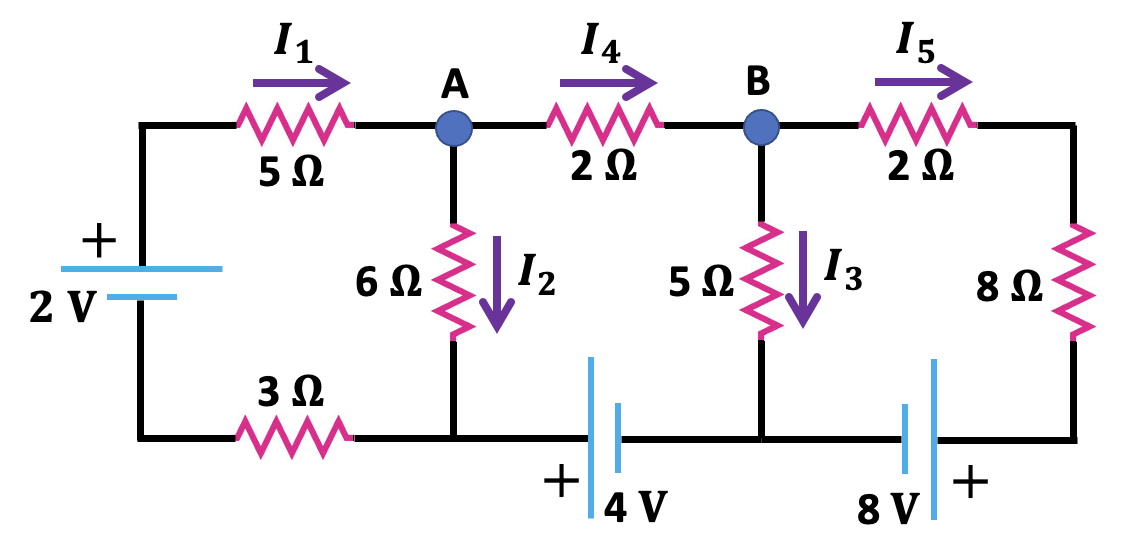


For this lab, you will need to use Kirhoff's rules to determine the unknown values of the problem. As a reminder, Kirchoff's Loop and Junction rules are:

$$\sum{V} = 0 \hspace{1in} \text{Loop Rule}$$

$$\sum{I} = 0 \hspace{0.8in} \text{Junction Rule}$$


#### Step 1: Work out **5** necessary equations to solve for all 5 unknown currents ($I_1, I_2, I_3, I_4, I_5$), and write them in markdown below. 

Use the three loops shown and apply the junction rule at points A and B. 

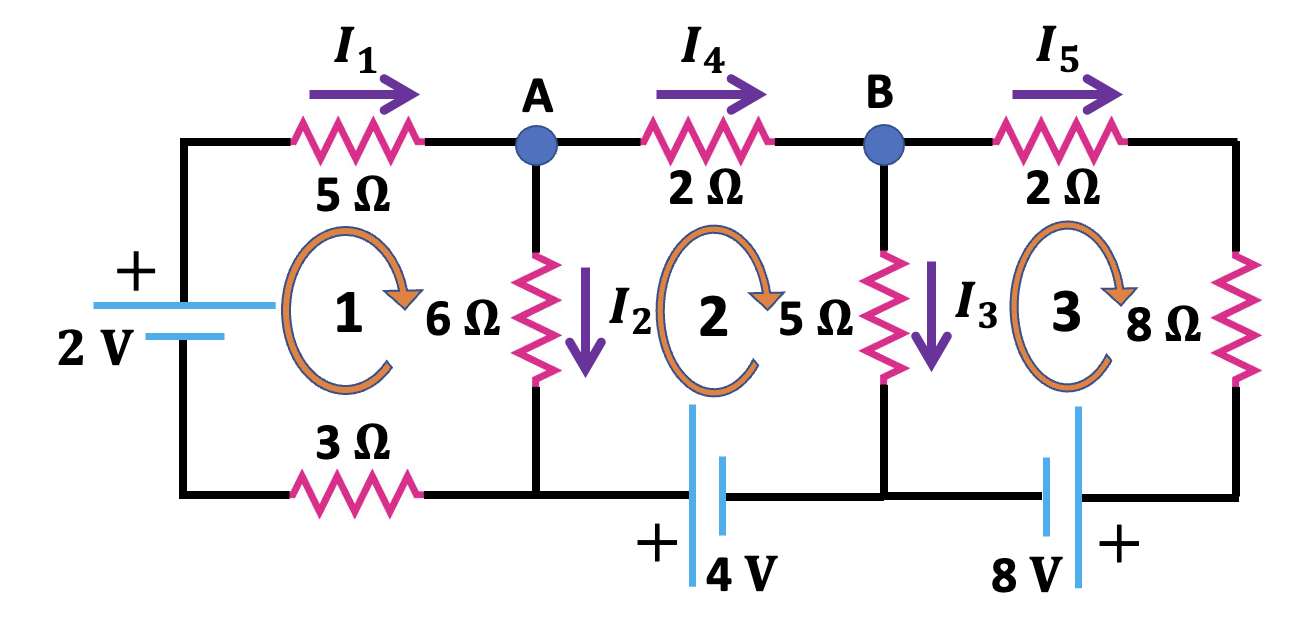


Rearrange so that you have all terms that depend on the unknowns on the left side of your equations and the constants on the right side. 

**Note:** If you can't see either of the images, find image 'Circuit.png', first image, or 'Circuit_3B.png', second image, on Moodle and replace the code above with the image name while making sure it is in the same location on your computer as this notebook. Then re-run this cell. 

Junction A: $I_1= I_4+I_2$   or

$1I_1-1I_2+0I_3-1I_4+0I_5=0$


Junction B: $I_4=I_5+I_3$   or

$0I_1-0I_2-1I_3+1I_4-1I_5=0$


Loop 1: The 3$\Omega$ resistor is in series with the 5$\Omega$ resistor with no junctions in between, so it's current is $I_1$. Therefore $(5\Omega)I_1+(6\Omega)I_2+(3\Omega)I_1=2V$   or

$8I_1+6I_2+0I_3+0I_4+0I_5=2$


Loop 2: $-(6\Omega)I_2+(2\Omega)I_4+(5\Omega)I_3=4V$   or

$0I_1-6I_2+5I_3+2I_4+0I_5=4$


Loop 3: The 8$\Omega$ resistor is in series with the 2$\Omega$ resistor with no junctions in between, so it's current is $I_5$. Therefore $-(5\Omega)I_3+(2\Omega)I_5+(8\Omega)I_5=-8V$   or

$0I_1+0I_2-5I_3+0I_4+10I_5=-8$

#### Step 2: Define three matrices/arrays: a matrix (using a numpy array) of the left side of the equation ($\bf{A}$), the array/matrix for the constants  ($\bf{v}$), and the matrix/array of variables you are solving for  ($\bf{x}$). *Keep all 5 equations with all 5 variables*

In [3]:
#array of left side of each equation
A = np.array([[1, -1,  0,  -1, 0],
             [0, 0, -1, 1, -1],
             [8, 6, 0,  0, 0], 
             [0, -6, 5,  2, 0],
             [0, 0, -5,  0, 10]], float)

#array of right side of each equation
v = np.array([0, 0, 2, 4, -8], float)

#array of same length to store results
N = len(v)
x=np.zeros(N,float)

#### Step 3: Create a function `Gauss_Elim(A,x,v)` that applies Gaussian Elimination with backsubstitution to solve for the currents.   You can use the code from class/the book as a reference. Think about whether or not pivoting might be necessary. 

In [4]:
def Gauss_Elim(A,x,v):
    #first, pivoting
    for m in range(N):
        biggest_first = np.abs(A[m,m]) #this variable stores the first non-zero variable of a row
                                        #it defaults to storing the first non-zero element of the current row
        biggest_first_row = m          #this variable stores the index of the row with the biggest first value
                                        #it defaults to the current row
        current_row = A[m,:].copy()   #stores current row for A
        current_row_v = v[m].copy()  #stores current row for v
        for j in range(m, N):     #loops through all rows below current row to find row with biggest first non-zero value
            if np.abs(A[j,m]) > biggest_first:
                biggest_first = np.abs(A[j,m])
                biggest_first_row = j
        #swap rows for A
        A[m,:] = A[biggest_first_row,:]
        A[biggest_first_row,:] = current_row
        #swap rows for v
        v[m] = v[biggest_first_row]
        v[biggest_first_row] = current_row_v
    
        diag = A[m,m] #diagonal component of row A
        A[m,:] = A[m,:]/diag #divide each component in row by diagonal component
        v[m]= v[m]/diag #divide row m in v by same value

        for i in range(m+1,N):
            first = A[i,m] #first nonzero element of each lower row
            A[i,:] -= first*A[m,:] #subtract appropriate multiple of top row from lower rows
            v[i] -= first*v[m]   #same for v

    #backsubstitution
    for m in range(N-1,-1,-1): #counts down from last to first index of matrix v
        x[m] = v[m] #for example x[3] = v[3]
        for i in range(m+1, N): 
            x[m] = x[m] - A[m,i]*x[i] #for example x = v1 - a12y - a13z

    return x

#### Step 4: Call on the function to determine the unknown currents and write out the resulting values ($I_1, I_2, I_3, I_4, I_5$). 

In [7]:
result = Gauss_Elim(A,x,v)

print("Current I1 =",result[0],"Current I2 =",result[1],"Current I3 =",result[2],"Current I4 =",result[3],\
"Current I5 =",result[4])

Current I1 = 0.24999999999999997 Current I2 = 2.7755575615628914e-17 Current I3 = 0.7000000000000001 Current I4 = 0.2499999999999999 Current I5 = -0.45


*Option:* If you find that Gaussian Elimination with pivoting still isn't working - use the two junction rules to replace $I_4$ and $I_5$ in terms of $I_1, I_2$, and $I_3$ making a 3x3 matrix instead. 

#### Step 5: What can you conclude about the currents in the figure? Were they chosen in the correct direction? Do the answers make sense? 

Currents $I_1$, $I_3$, and $I_4$ look right. Current $I_5$ however is negative. That means that the current flows the opposite way than how it is depicted. Current $I_2$ is very small, so there is essentially no current flowing through the $6\Omega$ resistor.

## LU Decomposition (10 pts)

Let's calculate the same currents, but using the LU decomposition method istead. 

#### Step 1: Setup and execute the necessary command(s) to analyze the matrices above using LU decomposition instead. If you're original 5x5 matrix didn't work with Gaussian Elimination, try it here!

In [8]:
#array of left side of each equation
A = np.array([[1, -1,  0,  -1, 0],
             [0, 0, -1, 1, -1],
             [8, 6, 0,  0, 0], 
             [0, -6, 5,  2, 0],
             [0, 0, -5,  0, 10]], float)

#array of right side of each equation
v = np.array([0, 0, 2, 4, -8], float)

# create array for results, x
x = np.linalg.solve(A,v)

print(A)
print(x)

[[ 1. -1.  0. -1.  0.]
 [ 0.  0. -1.  1. -1.]
 [ 8.  6.  0.  0.  0.]
 [ 0. -6.  5.  2.  0.]
 [ 0.  0. -5.  0. 10.]]
[ 0.25 -0.    0.7   0.25 -0.45]


#### Step 2: Include a markdown explaining the process and result of both ways of analyzing linear equations. Include how your answer compares to the answers from Gaussian Elimination above.  

#### Method 1
In step 1, I used the junction and loop rules to write out five equations and rearranged them to find all of the coefficients to put in the A and v arrays in step 2. In step 3, I used the code I wrote in the class notebook within a function. The code runs through each row and does the following. First, it does pivoting. I decided this was necessary because two rows in the matrix start with zero, and there are other zeros throughout that the code might run into. It stores the values of the current row for A and v. It also stores the first non-zero value of the current row (which is the diagonal element). Then it runs through each row after the current row and checks whether the first non-zero element of that row (which is in the same column for each row) is further from zero than any previous first value. If it is, it stores the index of that row. After all rows are checked, the code swaps the current row with the row with the biggest first value for both A and v.

After pivoting is complete, the code finds the diagonal element in the current row and divides the whole row by that, as well as the corresponding row in v. Then, for each lower row in the matrix, it finds the first non-zero element in the row and subtracts the current row times that value.

After the entire matrix is completely zeros below the diagonal, backsubstitution is performed. First, the final element of the solution matrix is set to the final element in v. This value is then used to solve the next equation up in the system. So if z=2, that is plugged into y+2z=3, which is solved and then plugged into the next equation up and so on. The coefficients for these equations are found in the A and v matrices.

#### Method 2:
Method 2 does all that work in a single line using numpys linear algebra module.

#### Comparison:
My answers for both methods were pretty much the same, but the values from method 2 were nicely rounded with no trailing 9s or 0s. The value that was of the order 1e-17 in method 1 (around expected computer rounding error) was simply 0 in method 2, implying that in reality it is 0 and rounding error created a non-zero value.